In [1]:
import pandas as pd
import requests
from io import StringIO

from UniversoActivos import UniversoActivosDinamico, UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Modelos import RandomForestModel
from Backtest import BacktestEngine

In [2]:
csv_path = r"c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

print(f"Número de tickers: {len(tickers)}")
print(tickers[:10])

tickers_por_categoria = (
    df.groupby("Category")["Ticker"]
      .apply(lambda s: sorted(s.dropna().astype(str).str.strip().unique().tolist()))
      .to_dict()
)

print(tickers_por_categoria["Sector"])

tickers = tickers + ["SPY"]

Número de tickers: 42
['XLC', 'XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLRE', 'XLK']
['XLB', 'XLC', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLRE', 'XLU', 'XLV', 'XLY']


[**********************88%*****************      ]  38 of 43 completed$SEA: possibly delisted; no price data found  (1d 2015-01-01 -> 2022-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1641013200")
[*********************100%***********************]  43 of 43 completed

1 Failed download:
['SEA']: possibly delisted; no price data found  (1d 2015-01-01 -> 2022-01-01) (Yahoo error = "Data doesn't exist for startDate = 1420088400, endDate = 1641013200")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:54: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to si

=== Métricas ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:189: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '11.12%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fmt.loc[c] = fmt.loc[c].map(lambda x: f"{x:.2%}")
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:189: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '82.23%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  fmt.loc[c] = fmt.loc[c].map(lambda x: f"{x:.2%}")


,ML,B&H EW
Total,11.12%,82.23%
CAGR,2.12%,12.70%
Vol,16.91%,17.46%
Sharpe,0.09,0.66
MaxDD,-30.09%,-33.16%
Hit,59.77%,65.90%


=== Rentabilidad Anual ===


c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\Backtest.py:195: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  [(1+ret_ml).resample("Y").prod()-1, (1+ret_bh).resample("Y").prod()-1], axis=1


,ML,B&H EW
Fecha,,
2017,21.65%,18.76%
2018,-17.25%,-10.73%
2019,28.07%,25.22%
2020,-7.80%,11.22%
2021,-6.52%,23.42%


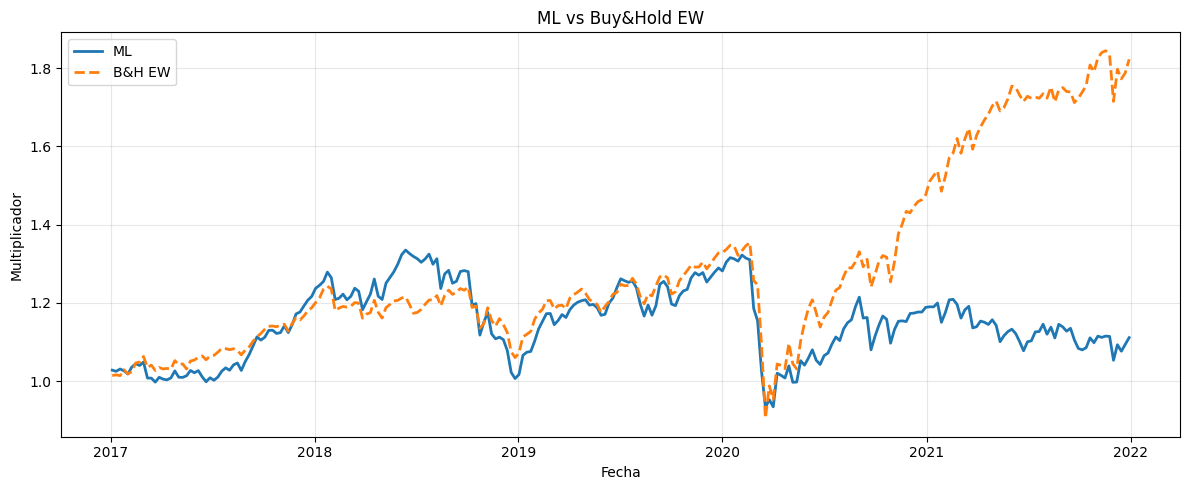

In [5]:
universo = UniversoActivosEstatico(tickers=tickers)

proveedor = YFinanceProvider(
    tickers    = tickers,
    start_date = "2015-01-01",
    end_date   = "2022-01-01"
)

fe = FeatureEngineer(criterio="mediana", ticker_indice="SPY")

modelo = RandomForestModel(positive_class_weight=1.0)

engine = BacktestEngine(
    universo         = universo,
    proveedor        = proveedor,
    feature_engineer = fe,
    modelo           = modelo,
    start_date       = "2015-01-01",  # ← añadido
    end_date         = "2022-01-01",  # ← añadido
    len_ventana      = 2,
    n_activos_obj    = 5,
    umbral_salida    = 7,
)

resultados, total = engine.run()